# Submitted by
- Maheer Helal
- maheer7helal@gmail.com
- 01823403010

In [ ]:
!pip -q install transformers==4.42.4 tokenizers==0.19.1 openpyxl==3.1.2

import os
import math
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer


In [1]:
import pandas as pd
from transformers import AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

# ---- File paths ----
PATH_TRAIN = "/kaggle/input/uiu-dataset/medical_dialogue_train.csv"
PATH_VALID = "/kaggle/input/uiu-dataset/medical_dialogue_validation.xlsx"
PATH_TEST  = "/kaggle/input/uiu-dataset/medical_dialogue_test.xlsx"

# ---- Model ----
MODEL_ID = "GanjinZero/biobart-v2-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# ---- Load ----
splits = {
    "train": pd.read_csv(PATH_TRAIN),
    "valid": pd.read_excel(PATH_VALID),
    "test":  pd.read_excel(PATH_TEST)
}

# ---- Verify structure ----
for name, df in splits.items():
    print(f"{name}: {df.shape}, columns: {df.columns.tolist()}")
    assert "dialogue" in df.columns and "soap" in df.columns, f"{name} missing required columns"


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

train: (9250, 2), columns: ['dialogue', 'soap']
valid: (500, 2), columns: ['dialogue', 'soap']
test: (250, 2), columns: ['dialogue', 'soap']


In [2]:
def get_token_lengths(texts, tokenizer):
    enc = tokenizer(texts, padding=False, truncation=False, add_special_tokens=True)
    return [len(ids) for ids in enc["input_ids"]]

stats = {}
for name, df in splits.items():
    inputs = df["dialogue"].astype(str).tolist()
    targets = df["soap"].astype(str).tolist()
    stats[name] = {
        "input_lens": get_token_lengths(inputs, tokenizer),
        "target_lens": get_token_lengths(targets, tokenizer)
    }

def summary(arr):
    a = np.array(arr)
    return {
        "count": len(a),
        "mean": np.mean(a),
        "std": np.std(a),
        "min": np.min(a),
        "50%": np.median(a),
        "95%": np.percentile(a, 95),
        "max": np.max(a)
    }

for split in stats:
    print(f"\n=== {split.upper()} ===")
    for field in ["input_lens", "target_lens"]:
        print(f"{field}: {summary(stats[split][field])}")



=== TRAIN ===
input_lens: {'count': 9250, 'mean': 637.7327567567568, 'std': 81.44618211462672, 'min': 323, '50%': 647.0, '95%': 757.0, 'max': 930}
target_lens: {'count': 9250, 'mean': 365.60843243243244, 'std': 60.68456657821637, 'min': 154, '50%': 366.0, '95%': 466.0, 'max': 600}

=== VALID ===
input_lens: {'count': 500, 'mean': 638.048, 'std': 76.6098537787405, 'min': 386, '50%': 644.0, '95%': 753.05, 'max': 838}
target_lens: {'count': 500, 'mean': 365.874, 'std': 59.36195855933327, 'min': 171, '50%': 367.0, '95%': 461.1999999999998, 'max': 553}

=== TEST ===
input_lens: {'count': 250, 'mean': 642.284, 'std': 83.75427955633073, 'min': 373, '50%': 656.0, '95%': 753.55, 'max': 808}
target_lens: {'count': 250, 'mean': 366.136, 'std': 64.65401382744926, 'min': 210, '50%': 368.0, '95%': 474.2999999999999, 'max': 564}


Saved: token_plots/input_lens.jpeg


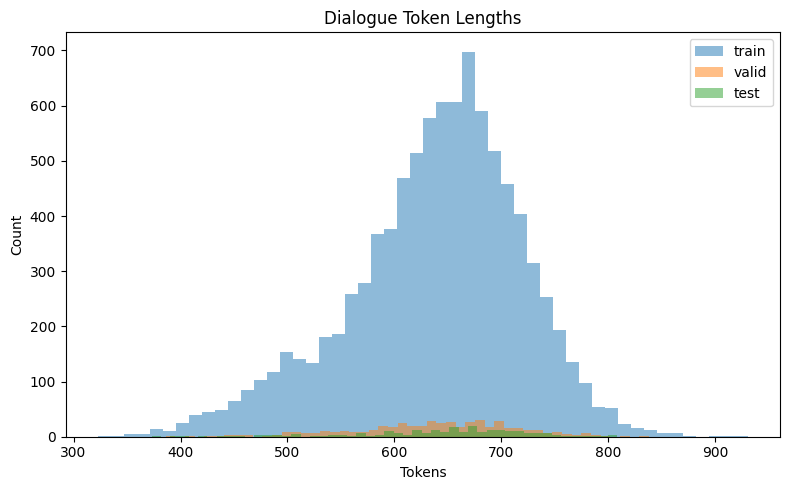

Saved: token_plots/target_lens.jpeg


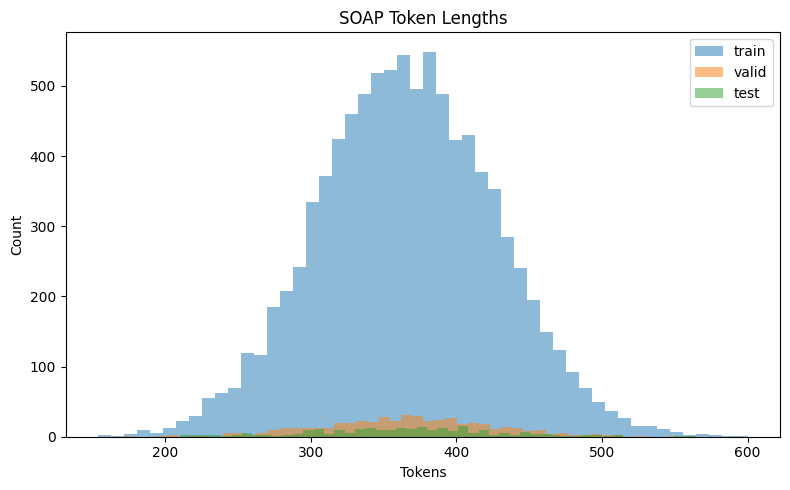

In [4]:
import os

# create folder for saving plots
os.makedirs("token_plots", exist_ok=True)

for field, title in zip(["input_lens", "target_lens"], ["Dialogue Token Lengths", "SOAP Token Lengths"]):
    plt.figure(figsize=(8,5))
    for split, data in stats.items():
        plt.hist(data[field], bins=50, alpha=0.5, label=split)
    plt.title(title)
    plt.xlabel("Tokens")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()

    filename = f"token_plots/{field}.jpeg"
    plt.savefig(filename, dpi=300, bbox_inches="tight", format="jpeg")
    print(f"Saved: {filename}")

    plt.show()

